In [1]:
import time

---

# **Exercise 1**

# Question 1: 

In [2]:
# Sorted Data in ascending order
Set1 = [2,4,6,8,9,9,9,10,12,14,16,18,20,22,24]
Set2 = [3,3,5,7,9,11,12,12,12,13,15,17,19,21,23]
Set3 = [3,4,6,6,9,11,11,12,15,17,17,17,18,21,21,24]
Set4 = [2,3,4,7,11,11,12,13,13,14,14,16,19,21,22,24]

targets = [140,165,182]

sets = [Set1, Set2, Set3, Set4]
for i in range(len(sets)):
    print(f"Set{i+1} : {len(sets[i])} items")

Set1 : 15 items
Set2 : 15 items
Set3 : 16 items
Set4 : 16 items


In [3]:
def issubsetsum_recursive(arr, n, target, subset=[]):
    # Base Cases
    if target == 0:
        print(f"Subset: {subset}")
        return True

    if n == 0 and target != 0:
        return False

    # Exclude if element > target
    if arr[n-1] > target:
        return issubsetsum_recursive(arr, n-1, target, subset)                  # Exclude

    # Include or Exclude last item
    return (
        issubsetsum_recursive(arr, n-1, target, subset) or                      # Exclude
        issubsetsum_recursive(arr, n-1, target-arr[n-1], subset+[arr[n-1]])     # Include
    )

---

# Question 2: 

In [4]:
def run_recursive(arr, target):
    start = time.time()
    found = issubsetsum_recursive(arr, len(arr), target)
    end = time.time()

    if not found:
        print("No Subset Found with given sum")

    print(f"Time taken: {(end-start)*1000:.3f} ms")
    print(f"\n{'--'*35}\n")

In [5]:
# Run
for s in sets:
    for t in targets:
        print(f"Set: {s}")
        print(f"Target {t}:")
        run_recursive(s,t)

Set: [2, 4, 6, 8, 9, 9, 9, 10, 12, 14, 16, 18, 20, 22, 24]
Target 140:
Subset: [22, 20, 18, 16, 14, 12, 9, 9, 8, 6, 4, 2]
Time taken: 6.977 ms

----------------------------------------------------------------------

Set: [2, 4, 6, 8, 9, 9, 9, 10, 12, 14, 16, 18, 20, 22, 24]
Target 165:
Subset: [24, 22, 20, 16, 14, 12, 10, 9, 9, 9, 8, 6, 4, 2]
Time taken: 16.789 ms

----------------------------------------------------------------------

Set: [2, 4, 6, 8, 9, 9, 9, 10, 12, 14, 16, 18, 20, 22, 24]
Target 182:
No Subset Found with given sum
Time taken: 14.385 ms

----------------------------------------------------------------------

Set: [3, 3, 5, 7, 9, 11, 12, 12, 12, 13, 15, 17, 19, 21, 23]
Target 140:
Subset: [21, 17, 15, 13, 12, 12, 12, 11, 9, 7, 5, 3, 3]
Time taken: 4.430 ms

----------------------------------------------------------------------

Set: [3, 3, 5, 7, 9, 11, 12, 12, 12, 13, 15, 17, 19, 21, 23]
Target 165:
Subset: [23, 21, 19, 15, 13, 12, 12, 12, 11, 9, 7, 5, 3, 3]
Time ta

---

# Question 3: 

In [6]:
def subset_sum(numbers, target_sum):
    n = len(numbers)

    dp = [[False]*(target_sum+1) for _ in range(n+1)]   # Time Complexity : O(n x sum)

    # Base case
    for i in range(n+1):
        dp[i][0] = True

    # Fill table
    for i in range(1, n+1):
        for j in range(1, target_sum+1):
            # Exclude numbers[i-1] if it exceeds target
            if j < numbers[i-1]:            
                dp[i][j] = dp[i-1][j]       # copy from above cells
            else:
                # Exclude or Include numbers[i-1] if it doesnot exceeds target
                dp[i][j] = dp[i-1][j] or dp[i-1][j - numbers[i-1]] # think of multiplexer of OR gate

    # Traceback
    subset = []
    i, j = n, target_sum

    while i > 0 and j > 0:
        if dp[i][j] != dp[i-1][j]:
            subset.append(numbers[i-1])
            j -= numbers[i-1]
        i -= 1

    return dp[n][target_sum], subset[::-1]

---

# Question 4: 

In [7]:
def run_dp(arr, target):
    start = time.time()
    exists, subset = subset_sum(arr, target)
    end = time.time()

    if exists:
        print(f"Subset: {subset}")
    else:
        print("No Subset Found with given sum")

    print(f"Time taken: {(end-start)*1000:.3f} ms")
    print(f"\n{'--'*35}\n")

In [8]:
# Run
for s in sets:
    for t in targets:
        print(f"Set: {s}")
        print(f"Target: {t}")
        run_dp(s,t)

Set: [2, 4, 6, 8, 9, 9, 9, 10, 12, 14, 16, 18, 20, 22, 24]
Target: 140
Subset: [2, 4, 6, 8, 9, 9, 12, 14, 16, 18, 20, 22]
Time taken: 0.245 ms

----------------------------------------------------------------------

Set: [2, 4, 6, 8, 9, 9, 9, 10, 12, 14, 16, 18, 20, 22, 24]
Target: 165
Subset: [2, 4, 6, 8, 9, 9, 9, 10, 12, 14, 16, 20, 22, 24]
Time taken: 0.278 ms

----------------------------------------------------------------------

Set: [2, 4, 6, 8, 9, 9, 9, 10, 12, 14, 16, 18, 20, 22, 24]
Target: 182
No Subset Found with given sum
Time taken: 0.298 ms

----------------------------------------------------------------------

Set: [3, 3, 5, 7, 9, 11, 12, 12, 12, 13, 15, 17, 19, 21, 23]
Target: 140
Subset: [3, 3, 5, 7, 9, 11, 12, 12, 12, 13, 15, 17, 21]
Time taken: 0.212 ms

----------------------------------------------------------------------

Set: [3, 3, 5, 7, 9, 11, 12, 12, 12, 13, 15, 17, 19, 21, 23]
Target: 165
Subset: [3, 3, 5, 7, 9, 11, 12, 12, 12, 13, 15, 19, 21, 23]
Time take

---

# Question 5: 

In [9]:
import matplotlib.pyplot as plt

In [10]:
def measure_recursive(arr, target):
    start = time.time()
    issubsetsum_recursive(arr, len(arr), target)
    return (time.time()-start)*1000   

def measure_dp(arr, target):
    start = time.time()
    subset_sum(arr, target)
    return (time.time()-start)*1000   

Subset: [22, 20, 18, 16, 14, 12, 9, 9, 8, 6, 4, 2]
Subset: [21, 17, 15, 13, 12, 12, 12, 11, 9, 7, 5, 3, 3]
Subset: [18, 17, 17, 17, 15, 12, 11, 11, 9, 6, 4, 3]
Subset: [21, 19, 14, 14, 13, 13, 12, 11, 11, 7, 3, 2]


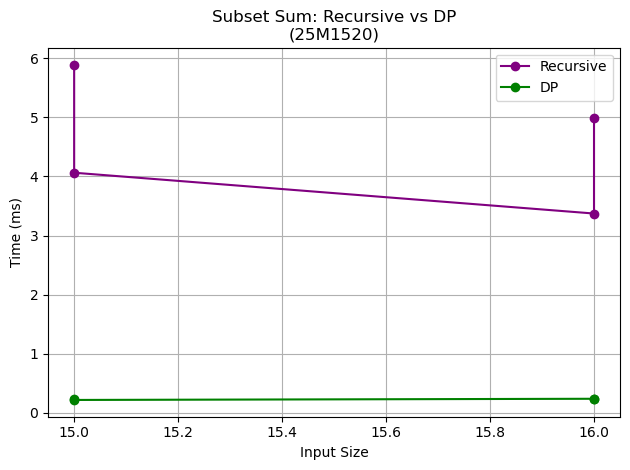

In [11]:
rec_times = [measure_recursive(s, targets[0]) for s in sets]    # target = 140
dp_times = [measure_dp(s, targets[0]) for s in sets]            # target = 140

sizes = [len(s) for s in sets]

plt.plot(sizes, rec_times, marker='o', label='Recursive', color="purple")
plt.plot(sizes, dp_times, marker='o', label='DP', color="green")

plt.xlabel("Input Size")
plt.ylabel("Time (ms)")  
plt.title("Subset Sum: Recursive vs DP\n(25M1520)")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

---

# **Exercise 2**

# Question 1: 

# ***Weighted Set Covering Integer Programming Formulation :***

### ***Sets and Parameters :***
Let $U$ be the set of all flights:
$$
U = \{1,2,3,4,5,6,7,8,9,10,11,12,13,14\}
$$

Let the set of crew sequences be:
$$
S = \{A,B,C,D,E,F,G,H,I\}
$$

### ***Coverage Sets $S_i$ :***
Each subset represents flights covered by a crew:
* $S_A = \{1,4,8,10\}$
* $S_B = \{2,5,9,12\}$
* $S_C = \{3,6,7,9\}$
* $S_D = \{1,9,11,14\}$
* $S_E = \{1,11,13\}$
* $S_F = \{2,4,8,10,14\}$
* $S_G = \{3,6,7,11,13\}$
* $S_H = \{2,4,8,10,14\}$
* $S_I = \{3,4,5,11,12\}$

### ***Costs :***
$c_A​=45, c_B​=45, c_C​=45, c_D​=45, c_E​=35, c_F​=55, c_G​=55,c_H​=60, c_I​=60$

### ***Decision Variables :***

Let $x_i$ be a binary:
$$
x_i = \begin{cases} 1 & \text{if crew sequence } i \text{ is selected}\\ 0 & \text{otherwise} \end{cases}
$$

### ***Objective Function (Minimize Cost) :***

The objective is to minimize
the total cost of the crew assignments that cover all the flights:
$$
\min Z = \sum_{i \in S} c_i x_i = \ 45x_A + 45x_B + 45x_C + 45x_D + 35x_E + 55x_F + 55x_G + 60x_H + 60x_I
$$

### ***Constraints :***
Each flight must be covered:
$$
\begin{aligned}
\text{Flight 1:} \quad & x_A + x_D + x_E \geq 1 \\
\text{Flight 2:} \quad & x_B + x_F + x_H \geq 1 \\
\text{Flight 3:} \quad & x_C + x_G + x_I \geq 1 \\
\text{Flight 4:} \quad & x_A + x_F + x_H + x_I \geq 1 \\
\text{Flight 5:} \quad & x_B + x_I \geq 1 \\
\text{Flight 6:} \quad & x_C + x_G \geq 1 \\
\text{Flight 7:} \quad & x_C + x_G \geq 1 \\
\text{Flight 8:} \quad & x_A + x_F + x_H \geq 1 \\
\text{Flight 9:} \quad & x_B + x_C + x_D \geq 1 \\
\text{Flight 10:} \quad & x_A + x_F + x_H \geq 1 \\
\text{Flight 11:} \quad & x_D + x_E + x_G + x_I \geq 1 \\
\text{Flight 12:} \quad & x_B + x_I \geq 1 \\
\text{Flight 13:} \quad & x_E + x_G \geq 1 \\
\text{Flight 14:} \quad & x_D + x_F + x_H \geq 1 \\
\\
\text{Binary Constraint:} \quad & x_i \in \{0, 1\}, \quad \forall i \in S
\end{aligned}
$$


Few constrains are repeating (**Flights {5,12}**, **Flights {6,7}**, **Flights {8,10}**) thus we required to mention the unique constraints only in our final LP model.

# ***Final LP Model :***

$$
\begin{aligned}
\text{Minimize} \quad & Z = \sum_{i \in S} c_i x_i \\
\text{subject to} \quad & \\
& x_A + x_D + x_E \geq 1 \\
& x_B + x_F + x_H \geq 1 \\
& x_C + x_G + x_I \geq 1 \\
& x_A + x_F + x_H + x_I \geq 1 \\
& x_B + x_I \geq 1 \\
& x_C + x_G \geq 1 \\
% & x_C + x_G \geq 1 \\
& x_A + x_F + x_H \geq 1 \\
& x_B + x_C + x_D \geq 1 \\
% & x_A + x_F + x_H \geq 1 \\
& x_D + x_E + x_G + x_I \geq 1 \\
% & x_B + x_I \geq 1 \\
& x_E + x_G \geq 1 \\
& x_D + x_F + x_H \geq 1 \\
& x_i \in \{0, 1\}, \quad \forall i \in S
\end{aligned}
$$

In [12]:
import pulp

# Flights (1 to 14)
U = list(range(1, 15))
# Crews (A to I)
crews = [*"ABCDEFGHI"] # equivalent to ['A','B','C','D','E','F','G','H','I']

# Subsets A–I
subsets = [
    [1,4,8,10],             # A
    [2,5,9,12],             # B
    [3,6,7,9],              # C
    [1,9,11,14],            # D
    [1,11,13],              # E
    [2,4,8,10,14],          # F
    [3,6,7,11,13],          # G
    [2,4,8,10,14],          # H
    [3,4,5,11,12]           # I
]

# Costs
costs = [45, 45, 45, 45, 35, 55, 55, 60, 60]

In [13]:
def solve_set_cover(U, subsets, costs, crews):
    start = time.time()

    m = len(subsets)
    x = pulp.LpVariable.dicts('x', range(m), 0, 1, pulp.LpBinary)
    prob = pulp.LpProblem("SetCover", pulp.LpMinimize)
    prob += pulp.lpSum(costs[j]*x[j] for j in range(m))
    for i in U:
        prob += pulp.lpSum(x[j] for j in range(m) if i in subsets[j]) >= 1
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    
    selected = [j for j in range(m) if x[j].value() == 1]
    selected_crews = [crews[j] for j in selected]
    end = time.time()

    covered = set()
    for s in selected:
        covered |= set(subsets[s])
    remains = set(U)-covered

    if len(remains):
        print("No feasible Solution Exists !!")
        print(f"Flight {remains} cannot be covered after selecting crews {selected_crews}")
        return None, (end-start)*1000
    else:
        total_cost = pulp.value(prob.objective)
        print("\n--- IP Solution ---")
        print("Selected crews:", selected_crews)
        print("Total cost:", total_cost)
        print("Time (ms):", (end-start)*1000)
        return total_cost, (end-start)*1000

In [14]:
ip_cost, ip_time = solve_set_cover(U, subsets, costs, crews)


--- IP Solution ---
Selected crews: ['B', 'C', 'E', 'F']
Total cost: 180.0
Time (ms): 12.857198715209961


---

# Question 2: 

# ***Greedy Formulation :***

### ***Problem Setup :***
* **Universe:**
$$
U = \{1, 2, \dots, 14\}
$$

* **Subsets:**
$S_A, S_B, \dots, S_I$

* **Costs:**
$c_A, c_B, \dots, c_I$

### ***Greedy Selection Rule :***
At each step, choose subset $S_i$ minimizing:
$$\frac{c_i}{|S_i - I|}$$
where:
* $I =$ already covered flights
* $S_i - I =$ uncovered flights covered by subset Algorithm 

### ***Steps :***
1. **Initialize:**
$$I = \emptyset$$

2. **While $I \neq U$:**
* Select subset $S_i$ minimizing:
$$\frac{c_i}{|S_i - I|}$$
* Update:
$$I = I \cup S_i$$

3. **Output selected subsets**

### ***Objective (Greedy Approximation):***
Minimize cost approximately:$$\sum_{i \in \text{selected}} c_i$$

In [15]:
def greedy_set_cover(U, subsets, costs, crews):
    start = time.time()

    I = set()
    selected = []

    while I != set(U):
        best = None
        best_ratio = float('inf')
        for j, S in enumerate(subsets):
            uncovered = set(S) - I
            if len(uncovered) > 0:
                ratio = costs[j] / len(uncovered)
                if ratio < best_ratio:
                    best_ratio = ratio
                    best = j
        if best == None:
            break
        selected.append(best)
        I |= set(subsets[best])

    selected_crews = [crews[j] for j in selected]
    end = time.time()

    covered = set()
    for s in selected:
        covered |= set(subsets[s])
    remains = set(U)-covered

    if len(remains):
        print("No feasible Solution Exists !!")
        print(f"Flight {remains} cannot be covered after selecting crews {selected_crews}")
        return None, (end-start)*1000
    else:
        total_cost = sum(costs[j] for j in selected)
        print("\n--- Greedy Solution ---")
        print("Selected crews:", selected_crews)
        print("Total cost:", total_cost)
        print("Time (ms):", (end-start)*1000)
        return total_cost, (end-start)*1000

In [16]:
gr_cost, gr_time = greedy_set_cover(U, subsets, costs, crews)


--- Greedy Solution ---
Selected crews: ['F', 'G', 'B', 'E']
Total cost: 190
Time (ms): 0.042438507080078125


---

# Question 3: 

# ***Remove Flights Chennai → Guwahati***
* #### ***remove constraint 11 : $x_D + x_E + x_G + x_I \geq 1$***
* #### ***remove crews D, E, G, I also (since crews must complete their full cyclic schedules, any crew assigned to the cancelled flight 11 becomes infeasible and is removed entirely from the problem. The set cover instance is then re-solved on the reduced universe and remaining crews)***
* #### ***Consequently the variables $x_D, x_E, x_G, x_I$ are eliminated***



# ***Modified LP Model :***

$$
\begin{aligned}
\text{Minimize} \quad & Z = 45x_A + 45x_B + 45x_C + 55x_F + 60x_H  \\
\text{subject to} \quad & \\
& x_A \geq 1 \\
& x_B + x_F + x_H \geq 1 \\
& x_C \geq 1 \\
& x_A + x_F + x_H \geq 1 \\
& x_B \geq 1 \\
& x_B + x_C \geq 1 \\
& x_F + x_H \geq 1 \\
& x_i \in \{0, 1\}, \quad \forall i \in S
\end{aligned}
$$

In [17]:
def remove_flights(U, subsets, costs, crews, removed):
    # Remove flights from universe
    U_new = [u for u in U if u not in removed]

    # Keep only those crews whose schedules do NOT include any cancelled flight
    keep_idx = [i for i, S in enumerate(subsets) if not any(f in removed for f in S)]

    subsets_new = [subsets[i] for i in keep_idx]
    costs_new   = [costs[i]   for i in keep_idx]
    crews_new   = [crews[i]   for i in keep_idx]

    return U_new, subsets_new, costs_new, crews_new

In [18]:
removed_flights = [11]

U_new, subsets_new, costs_new, crews_new = remove_flights(U, subsets, costs, crews, removed_flights)

In [19]:
print(f"""
U_new : {U_new}
subsets_new : {subsets_new}
costs_new : {costs_new}
crews_new : {crews_new}
""")


U_new : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14]
subsets_new : [[1, 4, 8, 10], [2, 5, 9, 12], [3, 6, 7, 9], [2, 4, 8, 10, 14], [2, 4, 8, 10, 14]]
costs_new : [45, 45, 45, 55, 60]
crews_new : ['A', 'B', 'C', 'F', 'H']



In [20]:
ip_cost2, ip_time2 = solve_set_cover(U_new, subsets_new, costs_new, crews_new)

No feasible Solution Exists !!
Flight {13, 14} cannot be covered after selecting crews ['A', 'B', 'C']


In [21]:
gr_cost2, gr_time2 = greedy_set_cover(U_new, subsets_new, costs_new, crews_new)

No feasible Solution Exists !!
Flight {13} cannot be covered after selecting crews ['F', 'C', 'B', 'A']


---

# Question 4: 

# ***Comparison***

In [22]:
def get_ratio(a, b):
    if a is None or b is None or b == 0:
        return "N/A"
    return a / b

In [ ]:
print(f"""
Original:
IP Time (ms): {ip_time}
Greedy Time (ms): {gr_time}
Cost Ratio (IP/Greedy): {get_ratio(ip_cost,gr_cost)}    

Modified:
IP Time (ms): {ip_time2}
Greedy Time (ms): {gr_time2}
Cost Ratio (IP/Greedy): {get_ratio(ip_cost2,gr_cost2)}
""")


Original:
IP Time (ms): 12.857198715209961
Greedy Time (ms): 0.042438507080078125
Cost Ratio (IP/Greedy): 0.9473684210526315

Modified:
IP Time (ms): 5.311250686645508
Greedy Time (ms): 0.04649162292480469
Cost Ratio (IP/Greedy): N/A



---